In [1]:
import os

print("Datasets available:")

for folder in os.listdir("/kaggle/input"):
    print(folder)

Datasets available:
datasets


In [2]:
import os

base_path = "/kaggle/input"

for root, dirs, files in os.walk(base_path):
    print(f"\nFolder: {root}")

    for file in files[:5]:
        print("   File:", file)


Folder: /kaggle/input

Folder: /kaggle/input/datasets

Folder: /kaggle/input/datasets/kushagra3204

Folder: /kaggle/input/datasets/kushagra3204/wheat-plant-diseases

Folder: /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data

Folder: /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/valid

Folder: /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/valid/black_rust_valid
   File: black_rust_19.png
   File: black_rust_0.png
   File: black_rust_7.png
   File: black_rust_4.png
   File: black_rust_8.png

Folder: /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/valid/brown_rust_valid
   File: brown_rust_test_45.png
   File: brown_rust_test_47.png
   File: brown_rust_test_38.png
   File: brown_rust_test_37.png
   File: brown_rust_test_42.png

Folder: /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/valid/aphid_valid
   File: aphid_76.png
   File: aphid_73.png
   File: aphid_66.png
   File: aphid_72.png
   File: aphid_59.png

Folder:

In [4]:

import os
from collections import Counter


base_path = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data"


image_extensions = (".png", ".jpg", ".jpeg")


for split in ["train", "test"]:
    split_path = os.path.join(base_path, split)

    print("\n" + "=" * 50)
    print(f"{split.upper()} DATASET")
    print("=" * 50)

    if not os.path.exists(split_path):
        print(f"{split} folder not found!")
        continue

    class_counts = {}

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            count = 0

            for file in os.listdir(class_path):
                if file.lower().endswith(image_extensions):
                    count += 1

            class_counts[class_name] = count

    total_images = sum(class_counts.values())

    print(f"Total images: {total_images}")
    print(f"Total classes: {len(class_counts)}")

    print("\nImages per class:")

    for class_name, count in class_counts.items():
        print(f"{class_name}: {count}")


TRAIN DATASET
Total images: 13104
Total classes: 15

Images per class:
Aphid: 903
Black Rust: 576
Blast: 647
Brown Rust: 1271
Common Root Rot: 614
Fusarium Head Blight: 611
Healthy: 1000
Leaf Blight: 842
Mildew: 1081
Mite: 800
Septoria: 1144
Smut: 1310
Stem fly: 234
Tan spot: 770
Yellow Rust: 1301

TEST DATASET
Total images: 750
Total classes: 15

Images per class:
aphid_test: 50
black_rust_test: 50
blast_test: 50
brown_rust_test: 50
common_root_rot_test: 50
fusarium_head_blight_test: 50
healthy_test: 50
leaf_blight_test: 50
mildew_test: 50
mite_test: 50
septoria_test: 50
smut_test: 50
stem_fly_test: 50
tan_spot_test: 50
yellow_rust_test: 50


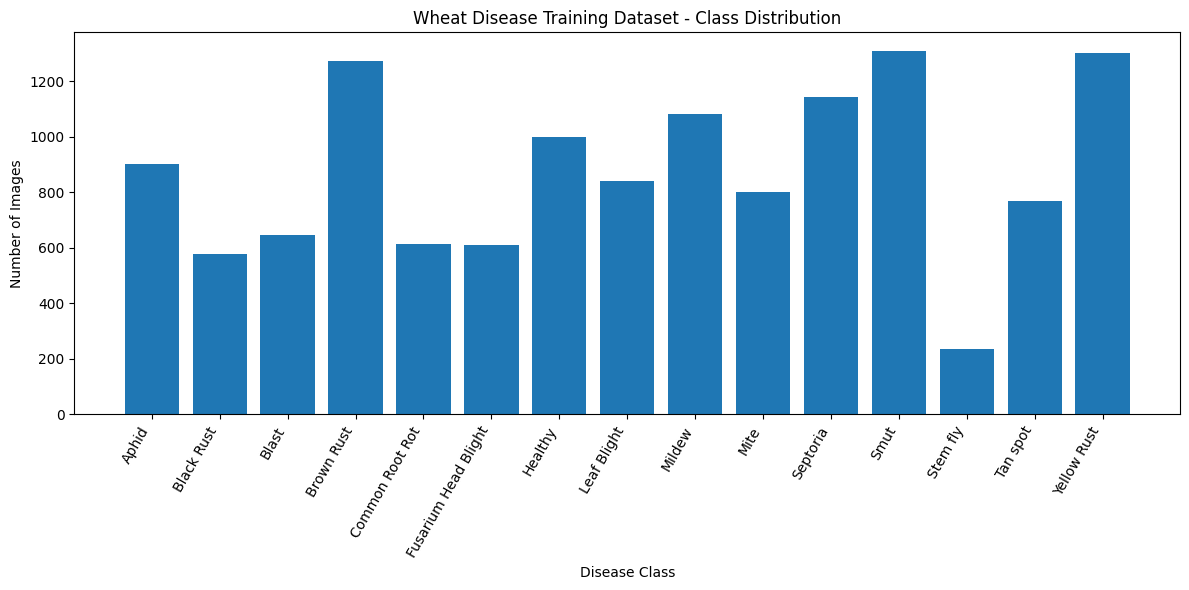

In [5]:

import os
import matplotlib.pyplot as plt


train_path = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train"

image_extensions = (".png", ".jpg", ".jpeg")

class_names = []
class_counts = []

for class_name in sorted(os.listdir(train_path)):
    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path):
        count = sum(
            1 for file in os.listdir(class_path)
            if file.lower().endswith(image_extensions)
        )

        class_names.append(class_name)
        class_counts.append(count)


plt.figure(figsize=(12, 6))

plt.bar(class_names, class_counts)

plt.title("Wheat Disease Training Dataset - Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

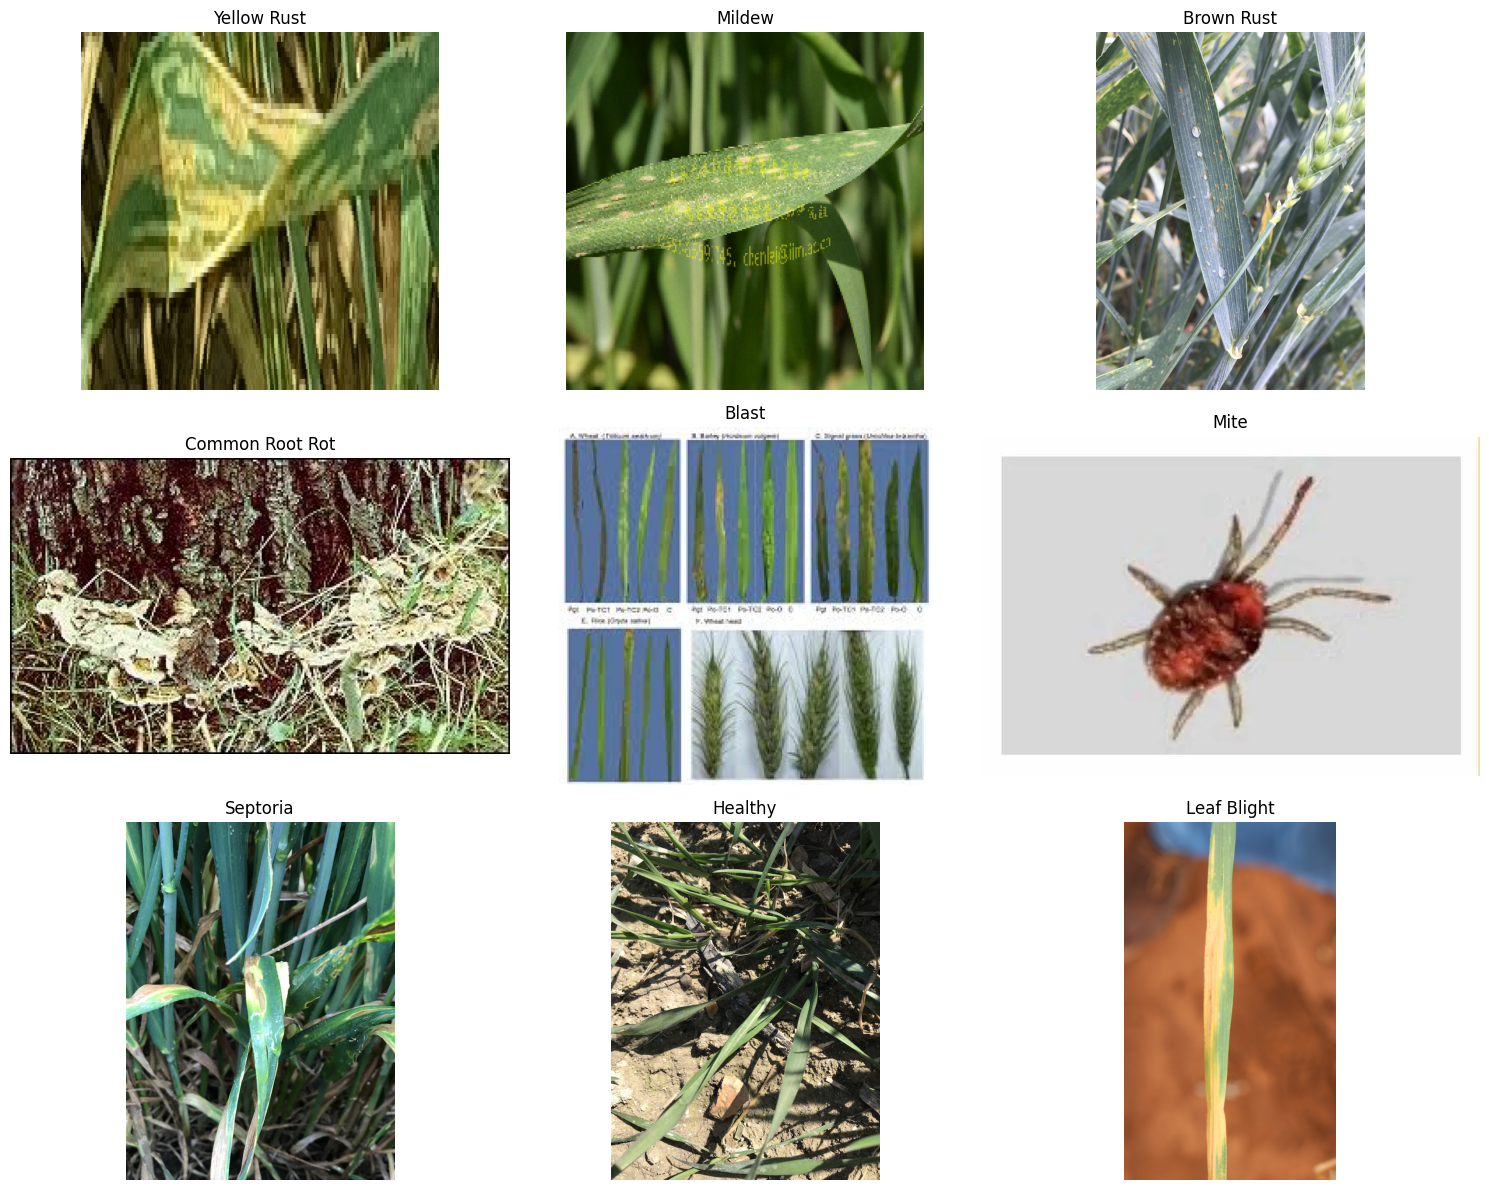

In [6]:

import os
import random
from PIL import Image
import matplotlib.pyplot as plt

train_path = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train"

# Available classes
classes = [
    folder for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
]

# Randomly select up to 9 classes/images
samples = []

for class_name in classes:
    class_path = os.path.join(train_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    if image_files:
        file_name = random.choice(image_files)
        file_path = os.path.join(class_path, file_name)
        samples.append((class_name, file_path))

# Select up to 9 samples
samples = samples[:9]

plt.figure(figsize=(15, 12))

for i, (class_name, file_path) in enumerate(samples):
    image = Image.open(file_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

import os
from PIL import Image
from collections import Counter

train_path = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train"

image_extensions = (".png", ".jpg", ".jpeg")

# Dimensions store karne ke liye
dimensions = []
total_images = 0
corrupted_images = []

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith(image_extensions):

            file_path = os.path.join(class_path, file_name)

            try:
                with Image.open(file_path) as img:
                    dimensions.append(img.size)
                    total_images += 1

            except Exception as e:
                corrupted_images.append(file_path)

print("Total images checked:", total_images)
print("Corrupted images:", len(corrupted_images))

# Most common image dimensions
dimension_counts = Counter(dimensions)

print("\nMost common image dimensions:")

for dimension, count in dimension_counts.most_common(15):
    print(f"{dimension}: {count} images")

Total images checked: 13104
Corrupted images: 0

Most common image dimensions:
(256, 256): 2877 images
(709, 945): 503 images
(275, 183): 419 images
(709, 471): 339 images
(259, 194): 329 images
(6000, 4000): 285 images
(738, 491): 231 images
(567, 756): 203 images
(194, 259): 158 images
(225, 225): 114 images
(300, 168): 111 images
(183, 275): 107 images
(2848, 4272): 88 images
(299, 168): 74 images
(3264, 1836): 65 images


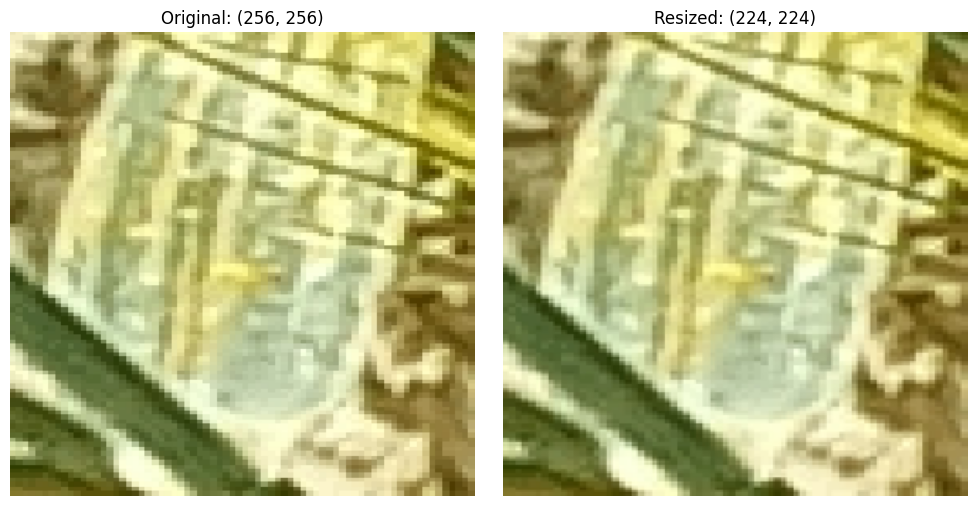

In [8]:

from PIL import Image
import matplotlib.pyplot as plt
import os

# Example image path
train_path = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train"

class_name = "Yellow Rust"

class_path = os.path.join(train_path, class_name)

image_files = [
    file for file in os.listdir(class_path)
    if file.lower().endswith((".png", ".jpg", ".jpeg"))
]

image_path = os.path.join(class_path, image_files[0])

# Original image
image = Image.open(image_path).convert("RGB")

# Resize image
resized_image = image.resize((224, 224))

# Display original and resized images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Original: {image.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_image)
plt.title(f"Resized: {resized_image.size}")
plt.axis("off")

plt.tight_layout()
plt.show()

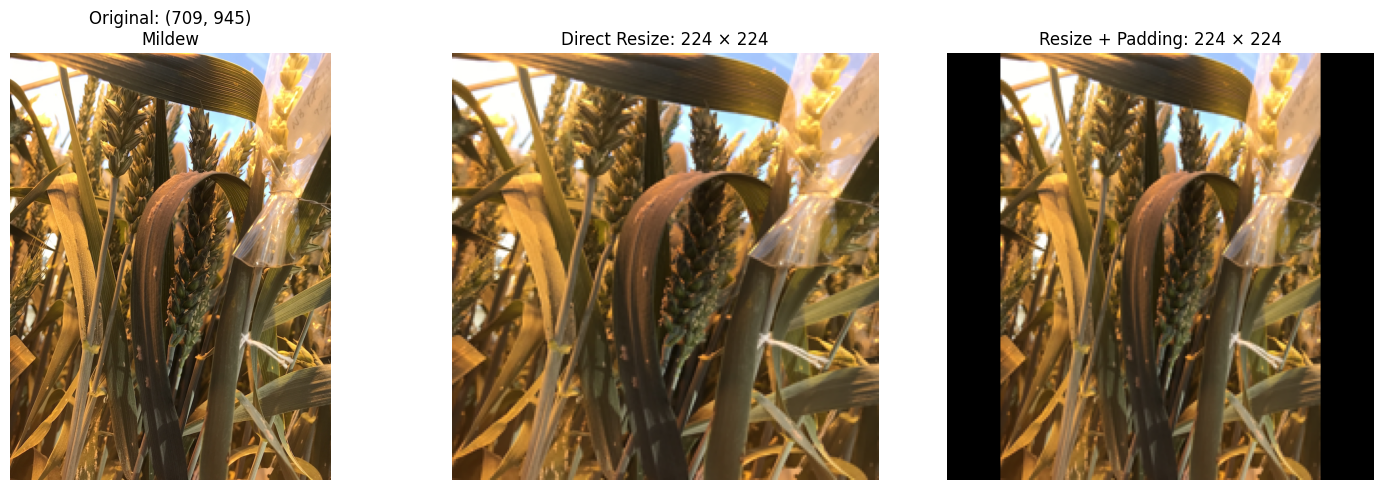

In [9]:

import os
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

train_path = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train"

image_extensions = (".png", ".jpg", ".jpeg")

# Find a non-square image
selected_image = None
selected_class = None

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith(image_extensions):

            file_path = os.path.join(class_path, file_name)

            with Image.open(file_path) as img:
                if img.width != img.height:
                    selected_image = file_path
                    selected_class = class_name
                    break

    if selected_image:
        break

# Open original image
image = Image.open(selected_image).convert("RGB")

# Direct resize
direct_resize = image.resize((224, 224))

# Aspect-ratio preserving resize + padding
preserved_resize = ImageOps.contain(image, (224, 224))

canvas = Image.new("RGB", (224, 224), (0, 0, 0))

x = (224 - preserved_resize.width) // 2
y = (224 - preserved_resize.height) // 2

canvas.paste(preserved_resize, (x, y))

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title(f"Original: {image.size}\n{selected_class}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(direct_resize)
plt.title("Direct Resize: 224 × 224")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(canvas)
plt.title("Resize + Padding: 224 × 224")
plt.axis("off")

plt.tight_layout()
plt.show()

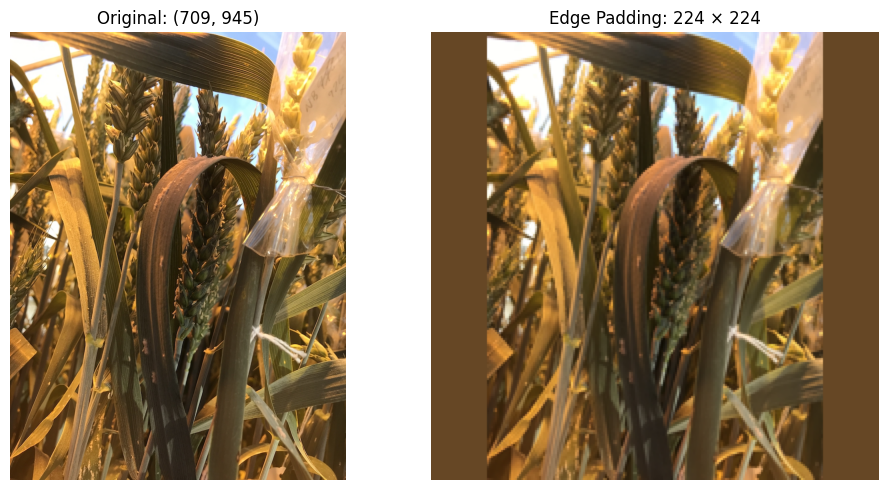

In [10]:

from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# Original image ko use kar rahe hain
image = Image.open(selected_image).convert("RGB")

target_size = (224, 224)

# Aspect-ratio preserve karte hue image resize
contained = ImageOps.contain(image, target_size)

# Edge color se padding fill karne ke liye
# Corner pixel ko padding color ke liye use karenge
edge_color = contained.getpixel((0, 0))

canvas = Image.new("RGB", target_size, edge_color)

# Center mein image paste karna
x = (target_size[0] - contained.width) // 2
y = (target_size[1] - contained.height) // 2

canvas.paste(contained, (x, y))

# Display
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Original: {image.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(canvas)
plt.title("Edge Padding: 224 × 224")
plt.axis("off")

plt.tight_layout()
plt.show()

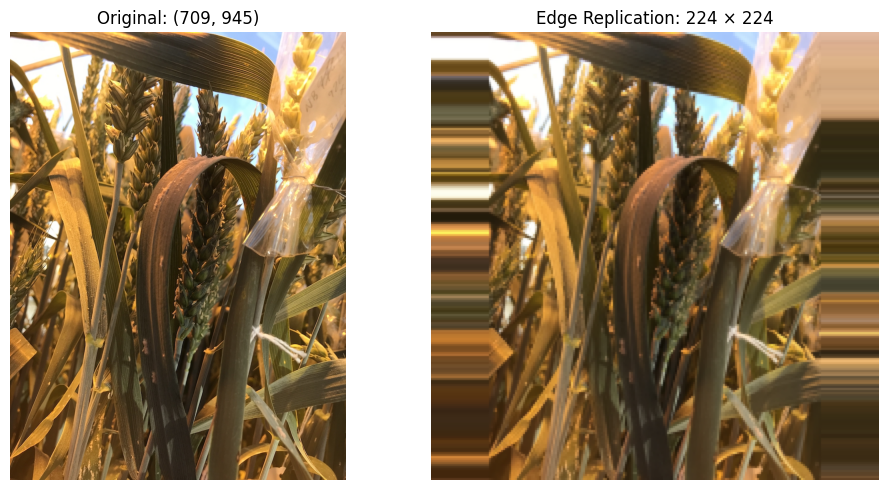

Final image shape: (224, 224, 3)


In [12]:

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# Original image
image = Image.open(selected_image).convert("RGB")

target_size = 224

# Original image ko NumPy array mein convert
img_array = np.array(image)

h, w = img_array.shape[:2]

# Aspect ratio preserve karte hue resize
scale = target_size / max(h, w)

new_w = max(1, int(round(w * scale)))
new_h = max(1, int(round(h * scale)))

resized = cv2.resize(
    img_array,
    (new_w, new_h),
    interpolation=cv2.INTER_AREA
)

# Required padding
pad_h = target_size - new_h
pad_w = target_size - new_w

top = pad_h // 2
bottom = pad_h - top

left = pad_w // 2
right = pad_w - left

# Edge pixels replicate karna
padded = cv2.copyMakeBorder(
    resized,
    top,
    bottom,
    left,
    right,
    borderType=cv2.BORDER_REPLICATE
)

# Display
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Original: {image.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(padded)
plt.title("Edge Replication: 224 × 224")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Final image shape:", padded.shape)

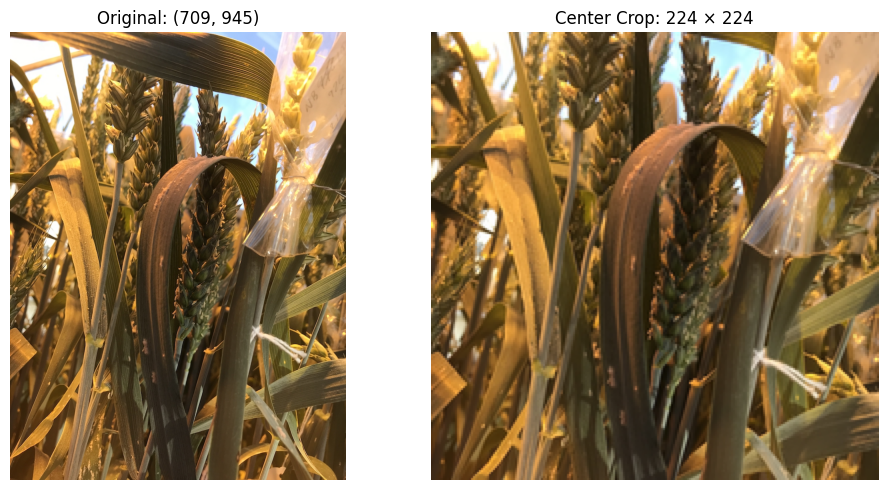

Final image size: (224, 224)


In [13]:

from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# Original image
image = Image.open(selected_image).convert("RGB")

# Center crop with aspect ratio preserved
center_crop = ImageOps.fit(
    image,
    (224, 224),
    method=Image.Resampling.LANCZOS,
    centering=(0.5, 0.5)
)

# Display comparison
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Original: {image.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(center_crop)
plt.title("Center Crop: 224 × 224")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Final image size:", center_crop.size)

In [14]:

import tensorflow as tf

# Dataset path
DATASET_DIR = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Training dataset (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Validation dataset (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Total classes:", len(class_names))

Found 13104 files belonging to 15 classes.
Using 10484 files for training.


2026-09-25 14:25:37.503428: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 13104 files belonging to 15 classes.
Using 2620 files for validation.
Classes: ['Aphid', 'Black Rust', 'Blast', 'Brown Rust', 'Common Root Rot', 'Fusarium Head Blight', 'Healthy', 'Leaf Blight', 'Mildew', 'Mite', 'Septoria', 'Smut', 'Stem fly', 'Tan spot', 'Yellow Rust']
Total classes: 15


In [16]:

import tensorflow as tf

print("TensorFlow version:", tf.__version__)

print("\nAvailable GPUs:")
gpus = tf.config.list_physical_devices("GPU")
print(gpus)

if gpus:
    print("\nGPU available hai!")
else:
    print("\nGPU available nahi hai. CPU use hoga.")

TensorFlow version: 2.20.0

Available GPUs:
[]

GPU available nahi hai. CPU use hoga.


In [17]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

print("Available GPUs:")
print(tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
Available GPUs:
[]
